# CNN on Fashion mnist/ other models as well

![](https://research.zalando.com/project/fashion_mnist/fashion_mnist/img/fashion-mnist-sprite.png)

# Context
> Fashion-MNIST is a dataset of Zalando's article images—consisting of a training set of 60,000 examples and a test set of 10,000 examples. 
> Each example is a 28x28 grayscale image, associated with a label from 10 classes. 
> Zalando intends Fashion-MNIST to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. 
> It shares the same image size and structure of training and testing splits.
> The original MNIST dataset contains a lot of handwritten digits. 
> Members of the AI/ML/Data Science community love this dataset and use it as a benchmark to validate their algorithms. 
> In fact, MNIST is often the first dataset researchers try. "If it doesn't work on MNIST, it won't work at all", they said. 
> "Well, if it does work on MNIST, it may still fail on others."

# Content
Each image is 28 pixels in height and 28 pixels in width, for a total of 784 pixels in total. Each pixel has a single pixel-value associated with it, indicating the lightness or darkness of that pixel, with higher numbers meaning darker. This pixel-value is an integer between 0 and 255. The training and test data sets have 785 columns. The first column consists of the class labels (see above), and represents the article of clothing. The rest of the columns contain the pixel-values of the associated image.

- To locate a pixel on the image, suppose that we have decomposed x as x = i * 28 + j, where i and j are integers between 0 and 27. The pixel is located on row i and column j of a 28 x 28 matrix.
- For example, pixel31 indicates the pixel that is in the fourth column from the left, and the second row from the top, as in the ascii-diagram below.

# Labels

Each training and test example is assigned to one of the following labels:

- 0 T-shirt/top
- 1 Trouser
- 2 Pullover
- 3 Dress
- 4 Coat
- 5 Sandal
- 6 Shirt
- 7 Sneaker
- 8 Bag
- 9 Ankle boot

# Loading library

In [1]:
# importing the library 

import csv
import string
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img

# Loading our Data
Note:

Unlike other dataset these dataset we will not have the actual images provided, instead we will have the data serialized as csv files.

Take a look at how the data looks like within the csv file:

In [2]:
train_df = pd.read_csv("../input/fashionmnist/fashion-mnist_train.csv")
test_df = pd.read_csv("../input/fashionmnist/fashion-mnist_test.csv")

In [3]:
train_df.shape

(60000, 785)

In [4]:
test_df.shape

(10000, 785)

In [5]:
train_df.columns

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=785)

In [6]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
train_df.tail()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59999,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


As you can see, each file includes a header (the first line) and each subsequent data point is represented as a line that contains 785 values.

The first value is the label (the numeric representation of each letter) and the other 784 values are the value of each pixel of the image. Remember that the original images have a resolution of 28x28, which sums up to 784 pixels.

In [8]:
train_df.label.value_counts()

2    6000
9    6000
6    6000
0    6000
3    6000
4    6000
5    6000
8    6000
7    6000
1    6000
Name: label, dtype: int64

In [9]:
label = {0:"T-shirt/top",
1 :"Trouser",
2 :"Pullover",
3 :"Dress",
4 :"Coat",
5 :"Sandal",
6 :"Shirt",
7 :"Sneaker",
8 :"Bag",
9 :"Ankle boot"}

In [10]:
l =[j for i,j in label.items()]
l

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [11]:
import plotly.graph_objects as go

ll = train_df.label.value_counts()

fig = go.Figure(data=[go.Pie(labels=l,
                             values=ll.values)])
fig.update_traces(title = "Distribuiton of Items" )
fig.update_traces(hoverinfo='label+percent', textinfo='value', textfont_size=20,
                  marker=dict(line=dict(color='#000000', width=2)))
fig.show()

Parsing the dataset
We will create a function that should be able to read a file passed as input and return 2 numpy arrays, one containing the labels and one containing the 28x28 representation of each image within the file. These numpy arrays should have type float64.

A couple of things to keep in mind:

The first line contains the column headers, so you should ignore it.

Each successive line contains 785 comma-separated values between 0 and 255

The first value is the label

The rest are the pixel values for that picture

Tips:

csv.reader returns an iterable that returns a row of the csv file in each iteration. Following this convention, row[0] has the label and row[1:] has the 784 pixel values.

To reshape the arrays (going from 784 to 28x28), you can use functions such as np.array_split or np.reshape.

For type conversion of the numpy arrays, use the method np.ndarray.astype.

In [12]:
def parse_data_from_input(filename):
    with open(filename) as file:
        reader = csv.reader(file, delimiter=',')    
        imgs = []
        labels = []
        next(reader, None)
        for row in reader:
            label = row[0]
            data = row[1:]
            img = np.array(data).reshape((28, 28))

            imgs.append(img)
            labels.append(label)

    images = np.array(imgs).astype(float)
    labels = np.array(labels).astype(float)
    return images, labels

Test your function

Here we check that the we have properly loaded the training images as well as validation images.
We can also see the dimension of the our training images dataset as well as validation images.

In [13]:
# this will be the directory of our training set and validation set

TRAINING_FILE = '../input/fashionmnist/fashion-mnist_train.csv'
VALIDATION_FILE = '../input/fashionmnist/fashion-mnist_test.csv'

In [14]:
# loading the training file which is in csv format and printing the lines

with open(TRAINING_FILE) as training_file:
    line = training_file.readline()
    print(f"First line (header) looks like this:\n{line}")
    line = training_file.readline()
    print(f"Each subsequent line (data points) look like this:\n{line}")

First line (header) looks like this:
label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,pixel41,pixel42,pixel43,pixel44,pixel45,pixel46,pixel47,pixel48,pixel49,pixel50,pixel51,pixel52,pixel53,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,pixel64,pixel65,pixel66,pixel67,pixel68,pixel69,pixel70,pixel71,pixel72,pixel73,pixel74,pixel75,pixel76,pixel77,pixel78,pixel79,pixel80,pixel81,pixel82,pixel83,pixel84,pixel85,pixel86,pixel87,pixel88,pixel89,pixel90,pixel91,pixel92,pixel93,pixel94,pixel95,pixel96,pixel97,pixel98,pixel99,pixel100,pixel101,pixel102,pixel103,pixel104,pixel105,pixel106,pixel107,pixel108,pixel109,pixel110,pixel111,pixel112,pixel113,pixel114,pixel115,pixel116,pixel117,pixel118,pix

In [15]:
training_images, training_labels = parse_data_from_input(TRAINING_FILE)
validation_images, validation_labels = parse_data_from_input(VALIDATION_FILE)

print(f"Training images has shape: {training_images.shape}")
print(f"Training labels has shape: {training_labels.shape}")
print(f"Validation images has shape: {validation_images.shape}")
print(f"Validation labels has shape: {validation_labels.shape}")

Training images has shape: (60000, 28, 28)
Training labels has shape: (60000,)
Validation images has shape: (10000, 28, 28)
Validation labels has shape: (10000,)


# Visualizing the Training dataset¶
Now that we have converted the initial csv data into a format that is compatible with computer vision tasks, now we will take a moment to actually see how the images of the dataset look like:

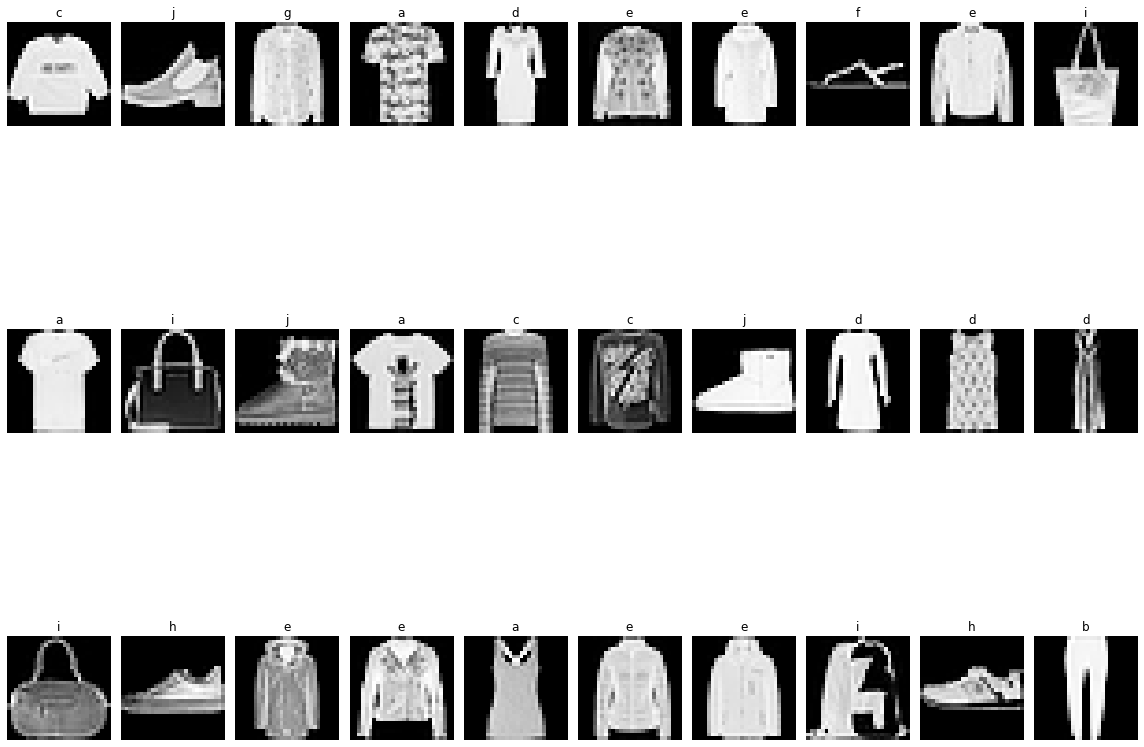

In [16]:
# Plot a sample of 30 images from the training set
def plot_categories(training_images, training_labels):
    fig, axes = plt.subplots(3, 10, figsize=(16, 15))
    axes = axes.flatten()
    letters = list(string.ascii_lowercase)

    for k in range(30):
        img = training_images[k]
        img = np.expand_dims(img, axis=-1)
        img = array_to_img(img)
        ax = axes[k]
        ax.imshow(img, cmap="Greys_r")
        ax.set_title(f"{letters[int(training_labels[k])]}")
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

plot_categories(training_images, training_labels)

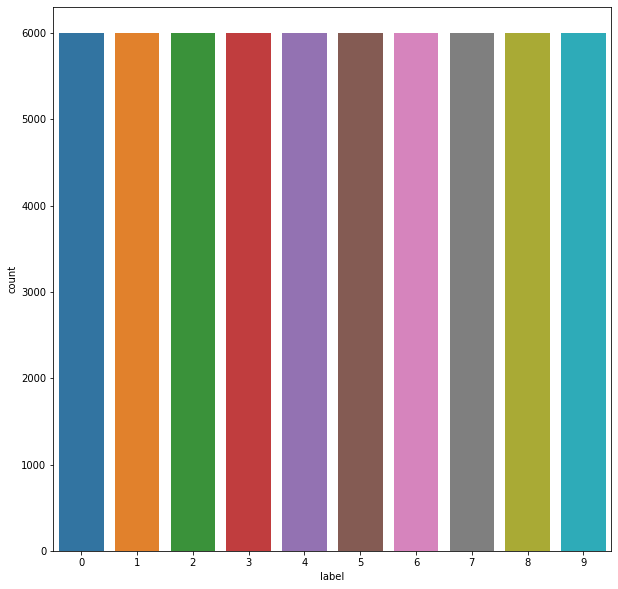

In [17]:
import seaborn as sns
plt.figure(figsize = (10,10)) 
sns.countplot(x=train_df['label'])
plt.show()

# Creating the generators for the CNN
Now that we have successfully organized the data in a way that can be easily fed to Keras' ImageDataGenerator, it is time to code the generators that will yield batches of images, both for training and validation.

Some important notes:

The images in this dataset come in the same resolution so you don't need to set a custom target_size in this case. In fact, we can't even do so because this time we will not be using the flow_from_directory method (as in previous assignments). Instead you will use the flow method.
You need to add the "color" dimension to the numpy arrays that encode the images. These are black and white images, so this new dimension should have a size of 1 (instead of 3, which is used when dealing with colored images). Take a look at the function np.expand_dims for this.

In [18]:
# In this section we will have to add another dimension to the data
# So, for example, if our array is (10000, 28, 28)
# We will need to make it (10000, 28, 28, 1)
# We can use np.expand_dims

def train_val_generators(training_images, training_labels, validation_images, validation_labels):
    training_images = np.expand_dims(training_images, axis=3)
    validation_images = np.expand_dims(validation_images, axis=3)

  # Instantiate the ImageDataGenerator class and also we need to normalize pixel values and set arguments to augment the images (if desired)
    train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


  
    train_generator = train_datagen.flow(x=training_images,
                                       y=training_labels,
                                       batch_size=32) 

  

    validation_datagen = ImageDataGenerator(
    rescale=1 / 255)

 
    validation_generator = validation_datagen.flow(x=validation_images,
                                                 y=validation_labels,
                                                 batch_size=32) 


    return train_generator, validation_generator


In [19]:
# Test our generators
train_generator, validation_generator = train_val_generators(training_images, training_labels, validation_images, validation_labels)

print(f"Images of training generator have shape: {train_generator.x.shape}")
print(f"Labels of training generator have shape: {train_generator.y.shape}")
print(f"Images of validation generator have shape: {validation_generator.x.shape}")
print(f"Labels of validation generator have shape: {validation_generator.y.shape}")

Images of training generator have shape: (60000, 28, 28, 1)
Labels of training generator have shape: (60000,)
Images of validation generator have shape: (10000, 28, 28, 1)
Labels of validation generator have shape: (10000,)


# Coding the CNN
One last step before training is to define the architecture of the model that will be trained.

Complete the create_model function below. This function should return a Keras' model that uses the Sequential or the Functional API.

The last layer of our model should have a number of units that corresponds to the number of possible categories, as well as the correct activation function.

Aside from defining the architecture of the model, we should also compile it so make sure to use a loss function that is suitable for multi-class classification.

Note that we should use no more than 2 Conv2D and 2 MaxPooling2D layers to achieve the desired performance.

In [20]:
def create_model():
    model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(26, activation='softmax')])
  

    model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
   
  
    return model

In [21]:
# Save our model for later use
model = create_model()

2022-03-31 13:52:57.241882: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-03-31 13:52:57.325856: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-03-31 13:52:57.326641: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-03-31 13:52:57.328489: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

In [22]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 13, 13, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 11, 11, 32)        9248      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 5, 5, 32)          0         
_________________________________________________________________
flatten (Flatten)            (None, 800)               0         
_________________________________________________________________
dense (Dense)                (None, 512)               410112    
_________________________________________________________________
dense_1 (Dense)              (None, 26)                1

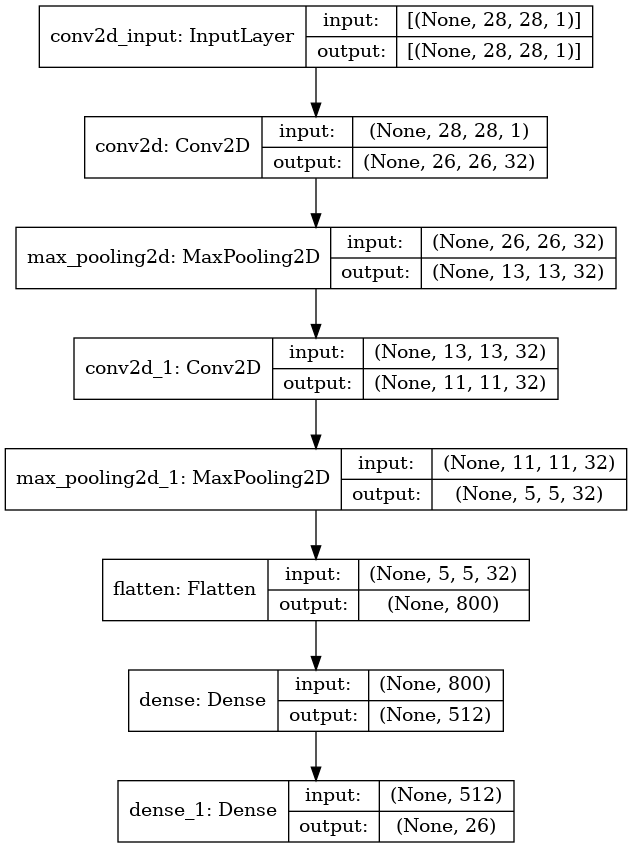

In [23]:
tf.keras.utils.plot_model(model, show_shapes=True)

- Ignore warnings

In [24]:
# Train our model
history = model.fit(train_generator,
                    epochs=30,
                    validation_data=validation_generator)

2022-03-31 13:53:00.593759: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/30


2022-03-31 13:53:01.828607: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


1875/1875 [==============================] - 30s 12ms/step - loss: 1.0524 - accuracy: 0.6131 - val_loss: 0.6381 - val_accuracy: 0.7555
Epoch 2/30
1875/1875 [==============================] - 24s 13ms/step - loss: 0.7613 - accuracy: 0.7185 - val_loss: 0.6729 - val_accuracy: 0.7397
Epoch 3/30
1875/1875 [==============================] - 23s 12ms/step - loss: 0.6738 - accuracy: 0.7518 - val_loss: 0.5569 - val_accuracy: 0.7899
Epoch 4/30
1875/1875 [==============================] - 23s 12ms/step - loss: 0.6262 - accuracy: 0.7694 - val_loss: 0.5350 - val_accuracy: 0.8017
Epoch 5/30
1875/1875 [==============================] - 23s 12ms/step - loss: 0.5955 - accuracy: 0.7790 - val_loss: 0.4913 - val_accuracy: 0.8193
Epoch 6/30
1875/1875 [==============================] - 24s 13ms/step - loss: 0.5716 - accuracy: 0.7879 - val_loss: 0.4631 - val_accuracy: 0.8262
Epoch 7/30
1875/1875 [==============================] - 23s 12ms/step - loss: 0.5522 - accuracy: 0.7958 - val_loss: 0.4287 - val_accura

# Now take a look at our training history:

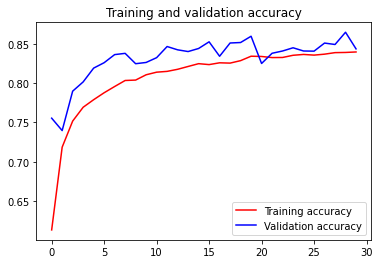

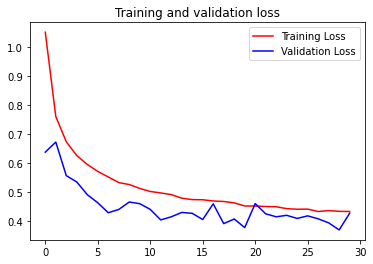

In [25]:
# Plot the chart for accuracy and loss on both training and validation
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

# Conclusion:
A reasonable benchmark is to achieve over 90% accuracy for training and over 95% accuracy for validation within 30 epochs. Try tweaking your model's architecture or the augmentation techniques to see if you can achieve these levels of accuracy.